# 흥행 영화의 특징은 무엇인가?
## TMDB 데이터 기반 흥행 결정 요인 분석

### 폰트 설정

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

### 패키지 설치

In [2]:
%pip install pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### import 구성

In [3]:
# 데이터 처리
import pandas as pd
import numpy as np
import ast
import os

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.preprocessing import StandardScaler # 정규화
from sklearn.decomposition import PCA            # 차원 축소
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## Step 1. 데이터 전처리

In [4]:
INPUT_PATH  = r'C:\Users\jinhu\OneDrive\바탕 화면\파이썬 프로젝트\월 데이터마이닝\TMDB_Datamining\data\TMDB_all_movies.csv'
OUTPUT_PATH = r'C:\Users\jinhu\OneDrive\바탕 화면\파이썬 프로젝트\월 데이터마이닝\TMDB_Datamining\data\tmdb_final.csv'

def run_preprocessing(input_path=INPUT_PATH, output_path=OUTPUT_PATH):
    scaled_path = os.path.join(os.path.dirname(output_path), 'tmdb_final_scaled.csv')
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    KEEP_COLS = [
        'budget', 'revenue', 'genres', 'popularity',
        'vote_average', 'vote_count', 'runtime', 'release_date',
        'original_language', 'director', 'cast',
        'imdb_rating', 'imdb_votes', 'status'
    ]

    print("=" * 50)
    print("Step 1: 데이터 로드 및 컬럼 선택")
    print("=" * 50)
    df = pd.read_csv(input_path)
    print(f"원본 데이터: {df.shape[0]:,}행 · {df.shape[1]}컬럼")
    df = df[KEEP_COLS]
    print(f"컬럼 선택 후: {df.shape[0]:,}행 · {df.shape[1]}컬럼")

    print("\n" + "=" * 50)
    print("Step 2: 유효 데이터 필터링")
    print("=" * 50)
    df = df[df['status'] == 'Released']
    print(f"Released 필터링: {df.shape[0]:,}행")
    df = df[(df['budget'] > 10000) & (df['revenue'] > 10000)]
    print(f"budget/revenue 필터링: {df.shape[0]:,}행")
    df = df.drop(columns=['status'])

    print("\n" + "=" * 50)
    print("Step 3: 핵심 변수 결측치 제거")
    print("=" * 50)
    before = len(df)
    df = df.dropna(subset=['genres', 'release_date', 'runtime'])
    print(f"결측치 제거: {before:,} → {len(df):,}행 ({before-len(df):,}개 제거)")

    print("\n" + "=" * 50)
    print("Step 4: 이상치 처리 (IQR × 1.5)")
    print("=" * 50)
    for col in ['budget', 'revenue', 'runtime']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        before = len(df)
        df = df[(df[col] >= lower) & (df[col] <= upper)]
        print(f"{col}: {before:,} → {len(df):,}행 ({before-len(df):,}개 제거)")
        print(f"  기준: {lower:,.0f} ~ {upper:,.0f}")

    print("\n" + "=" * 50)
    print("Step 5: 날짜 파생 변수 생성")
    print("=" * 50)
    df['release_date'] = pd.to_datetime(df['release_date'])
    df['year']  = df['release_date'].dt.year
    df['month'] = df['release_date'].dt.month
    df['season'] = df['month'].map({
        12: 4, 1: 4, 2: 4,
        3: 1,  4: 1, 5: 1,
        6: 2,  7: 2, 8: 2,
        9: 3, 10: 3, 11: 3
    })
    df = df.drop(columns=['release_date'])
    print("year, month, season 파생 변수 생성 완료")
    print(f"season 분포:\n{df['season'].value_counts().sort_index().rename({1:'봄',2:'여름',3:'가을',4:'겨울'})}")

    print("\n" + "=" * 50)
    print("Step 6: 장르 원-핫 인코딩")
    print("=" * 50)
    def parse_genres(g):
        try:
            items = ast.literal_eval(g)
            if isinstance(items, list):
                return [i['name'] if isinstance(i, dict) else i for i in items]
        except:
            pass
        if isinstance(g, str) and ',' in g:
            return [x.strip() for x in g.split(',')]
        return [g] if isinstance(g, str) and g else []

    df['genres_list'] = df['genres'].apply(parse_genres)
    all_genres = set()
    df['genres_list'].apply(lambda x: all_genres.update(x))
    print(f"전체 장르 수: {len(all_genres)}개")
    print(f"장르 목록: {sorted(all_genres)}")
    for genre in sorted(all_genres):
        if genre:
            col_name = f"genre_{genre.replace(' ', '_').replace('-', '_')}"
            df[col_name] = df['genres_list'].apply(lambda x: 1 if genre in x else 0)
    genre_cols = [c for c in df.columns if c.startswith('genre_')]
    print(f"생성된 장르 컬럼: {len(genre_cols)}개")
    df = df.drop(columns=['genres', 'genres_list'])

    print("\n" + "=" * 50)
    print("Step 7: 감독/출연진 빈도 기반 변수화")
    print("=" * 50)
    df['director'] = df['director'].fillna('Unknown')
    df['cast']     = df['cast'].fillna('Unknown')
    director_counts = df['director'].value_counts()
    TOP_N_DIRECTOR  = 50
    top_directors   = set(director_counts.head(TOP_N_DIRECTOR).index)
    df['director_is_top'] = df['director'].apply(lambda x: 1 if x in top_directors else 0)
    print(f"상위 {TOP_N_DIRECTOR}명 감독 변수화 완료")
    print(f"상위 감독 영화 비율: {df['director_is_top'].mean()*100:.1f}%")

    def get_first_cast(cast_str):
        if pd.isna(cast_str) or cast_str == 'Unknown':
            return 'Unknown'
        try:
            items = ast.literal_eval(cast_str)
            if isinstance(items, list) and len(items) > 0:
                return items[0]['name'] if isinstance(items[0], dict) else items[0]
        except:
            pass
        return cast_str.split(',')[0].strip() if ',' in str(cast_str) else cast_str

    df['lead_actor'] = df['cast'].apply(get_first_cast)
    actor_counts     = df['lead_actor'].value_counts()
    TOP_N_ACTOR      = 50
    top_actors       = set(actor_counts.head(TOP_N_ACTOR).index)
    df['actor_is_top'] = df['lead_actor'].apply(lambda x: 1 if x in top_actors else 0)
    print(f"상위 {TOP_N_ACTOR}명 배우 변수화 완료")
    print(f"상위 배우 영화 비율: {df['actor_is_top'].mean()*100:.1f}%")
    df = df.drop(columns=['director', 'cast', 'lead_actor'])

    print("\n" + "=" * 50)
    print("Step 8: 나머지 결측치 처리")
    print("=" * 50)
    df['imdb_rating'] = df['imdb_rating'].fillna(df['imdb_rating'].median())
    df['imdb_votes']  = df['imdb_votes'].fillna(df['imdb_votes'].median())
    df['original_language'] = df['original_language'].fillna('unknown')
    print(f"결측치 현황:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"전체 결측치: {df.isnull().sum().sum()}개")

    print("\n" + "=" * 50)
    print("Step 9: 파생 변수 생성")
    print("=" * 50)
    df['roi'] = (df['revenue'] - df['budget']) / df['budget']
    threshold = df['revenue'].quantile(0.70)
    df['hit'] = (df['revenue'] >= threshold).astype(int)
    print(f"ROI 변수 생성 완료 (평균: {df['roi'].mean():.2f})")
    print(f"흥행 기준 revenue: ${threshold:,.0f}")
    print(f"흥행 비율: {df['hit'].mean()*100:.1f}% (상위 30%)")

    print("\n" + "=" * 50)
    print("Step 10: Z-Score 정규화")
    print("=" * 50)
    numeric_cols = [
        'budget', 'popularity', 'vote_average', 'vote_count',
        'runtime', 'imdb_rating', 'imdb_votes', 'year', 'roi'
    ]
    scaler = StandardScaler()
    df_scaled = df.copy()
    df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    print(f"정규화 적용 컬럼: {numeric_cols}")

    print("\n" + "=" * 50)
    print("최종 결과")
    print("=" * 50)
    df.to_csv(output_path, index=False)
    df_scaled.to_csv(scaled_path, index=False)
    print(f"최종 데이터셋: {df.shape[0]:,}행 · {df.shape[1]}컬럼")
    print(f"저장 완료: {output_path}")
    print(f"정규화 버전: {scaled_path}")
    print("\n컬럼 목록:")
    for col in df.columns:
        print(f"  - {col}")
    return df, df_scaled

df_pre, df_scaled_pre = run_preprocessing()

Step 1: 데이터 로드 및 컬럼 선택
원본 데이터: 1,191,754행 · 28컬럼
컬럼 선택 후: 1,191,754행 · 14컬럼

Step 2: 유효 데이터 필터링
Released 필터링: 1,170,020행
budget/revenue 필터링: 12,764행

Step 3: 핵심 변수 결측치 제거
결측치 제거: 12,764 → 12,557행 (207개 제거)

Step 4: 이상치 처리 (IQR × 1.5)
budget: 12,557 → 11,278행 (1,279개 제거)
  기준: -32,302,500 ~ 59,381,500
revenue: 11,278 → 9,997행 (1,281개 제거)
  기준: -44,250,000 ~ 77,750,000
runtime: 9,997 → 9,278행 (719개 제거)
  기준: 56 ~ 156

Step 5: 날짜 파생 변수 생성
year, month, season 파생 변수 생성 완료
season 분포:
season
봄     2192
여름    2101
가을    2758
겨울    2227
Name: count, dtype: int64

Step 6: 장르 원-핫 인코딩
전체 장르 수: 19개
장르 목록: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
생성된 장르 컬럼: 19개

Step 7: 감독/출연진 빈도 기반 변수화
상위 50명 감독 변수화 완료
상위 감독 영화 비율: 7.7%
상위 50명 배우 변수화 완료
상위 배우 영화 비율: 2.0%

Step 8: 나머지 결측치 처리
결측치 현황:
Series([], dtype: int64)
전체 결측치: 0개

Step 9: 파생

## 전처리 결과

**입력:** `TMDB_all_movies.csv`

**출력:**
- `tmdb_final_scaled.csv` 생성 - Z-score 정규화한 값

- `tmdb_final.csv` 생성 

## Step 2. 데이터 로드 및 기본 확인

In [5]:
df = pd.read_csv(r'C:\Users\jinhu\OneDrive\바탕 화면\파이썬 프로젝트\월 데이터마이닝\TMDB_Datamining\data\tmdb_final.csv')
df_scaled = pd.read_csv(r'C:\Users\jinhu\OneDrive\바탕 화면\파이썬 프로젝트\월 데이터마이닝\TMDB_Datamining\data\tmdb_final_scaled.csv')
print(f"데이터셋 크기: {df.shape}")
df.head()

데이터셋 크기: (9278, 35)


,budget,revenue,popularity,vote_average,vote_count,runtime,original_language,imdb_rating,imdb_votes,year,...,genre_Romance,genre_Science_Fiction,genre_TV_Movie,genre_Thriller,genre_War,genre_Western,director_is_top,actor_is_top,roi,hit
0,4000000.0,4257354.0,4.0661,5.900,2821.0,98.0,en,6.7,116918.0,1995,...,0,0,0,0,0,0,0,0,0.064339,0
1,21000000.0,12136938.0,2.1596,6.500,370.0,109.0,en,6.6,21066.0,1993,...,0,0,0,1,0,0,0,0,-0.422051,0
2,839727.0,23218000.0,7.9288,7.977,6018.0,119.0,en,8.2,493614.0,1941,...,0,0,0,0,0,0,0,0,26.649462,1
3,12500000.0,40061153.0,3.4416,7.846,1975.0,140.0,en,7.9,123992.0,2000,...,0,0,0,0,0,0,0,0,2.204892,1
4,5300000.0,1350322.0,5.2261,8.089,3072.0,148.0,de,8.2,201170.0,1927,...,0,1,0,0,0,0,0,0,-0.745222,0


In [6]:
df.describe()

,budget,revenue,popularity,vote_average,vote_count,runtime,imdb_rating,imdb_votes,year,month,...,genre_Romance,genre_Science_Fiction,genre_TV_Movie,genre_Thriller,genre_War,genre_Western,director_is_top,actor_is_top,roi,hit
count,9.278000e+03,9.278000e+03,9278.000000,9278.000000,9278.000000,9278.000000,9278.000000,9.278000e+03,9278.000000,9278.000000,...,9278.000000,9278.000000,9278.000000,9278.000000,9278.000000,9278.000000,9278.000000,9278.000000,9278.000000,9278.000000
mean,1.031631e+07,1.405462e+07,2.784114,6.111389,682.135051,105.278724,6.256564,3.769952e+04,2000.170942,6.831537,...,0.199289,0.076310,0.001832,0.236473,0.034921,0.017353,0.077172,0.019832,3.198065,0.300065
std,1.159472e+07,1.802003e+07,4.229967,1.401626,1287.425369,17.391463,1.077590,8.624572e+04,20.728364,3.448222,...,0.399487,0.265507,0.042768,0.424939,0.183590,0.130589,0.266878,0.139430,20.850740,0.458310
min,1.009400e+04,1.001800e+04,0.000000,0.000000,0.000000,56.000000,1.100000,6.000000e+00,1914.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.999306,0.000000
25%,1.700000e+06,1.215112e+06,1.188425,5.700000,55.000000,93.000000,5.700000,3.269750e+03,1991.000000,4.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.600000,0.000000
50%,6.000000e+06,5.919500e+06,2.134200,6.300000,249.000000,102.000000,6.400000,1.302150e+04,2006.000000,7.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.235507,0.000000
75%,1.500000e+07,2.008437e+07,3.421825,6.900000,773.000000,115.000000,7.000000,3.965300e+04,2015.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.849717,1.000000
max,5.900000e+07,7.774597e+07,186.891200,10.000000,30236.000000,155.000000,9.500000,3.185576e+06,2026.000000,12.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,772.060240,1.000000


In [7]:
# 로그 변환
df['log_revenue'] = np.log1p(df['revenue'])
df['log_budget']  = np.log1p(df['budget'])
df['log_popularity'] = np.log1p(df['popularity'])

print(f"log_revenue 범위: {df['log_revenue'].min():.2f} ~ {df['log_revenue'].max():.2f}")
print(f"log_budget  범위: {df['log_budget'].min():.2f} ~ {df['log_budget'].max():.2f}")
print(f"log_popularity 범위: {df['log_popularity'].min():.2f} ~ {df['log_popularity'].max():.2f}")

log_revenue 범위: 9.21 ~ 18.17
log_budget  범위: 9.22 ~ 17.89
log_popularity 범위: 0.00 ~ 5.24


## Step 3. EDA (탐색적 데이터 분석)



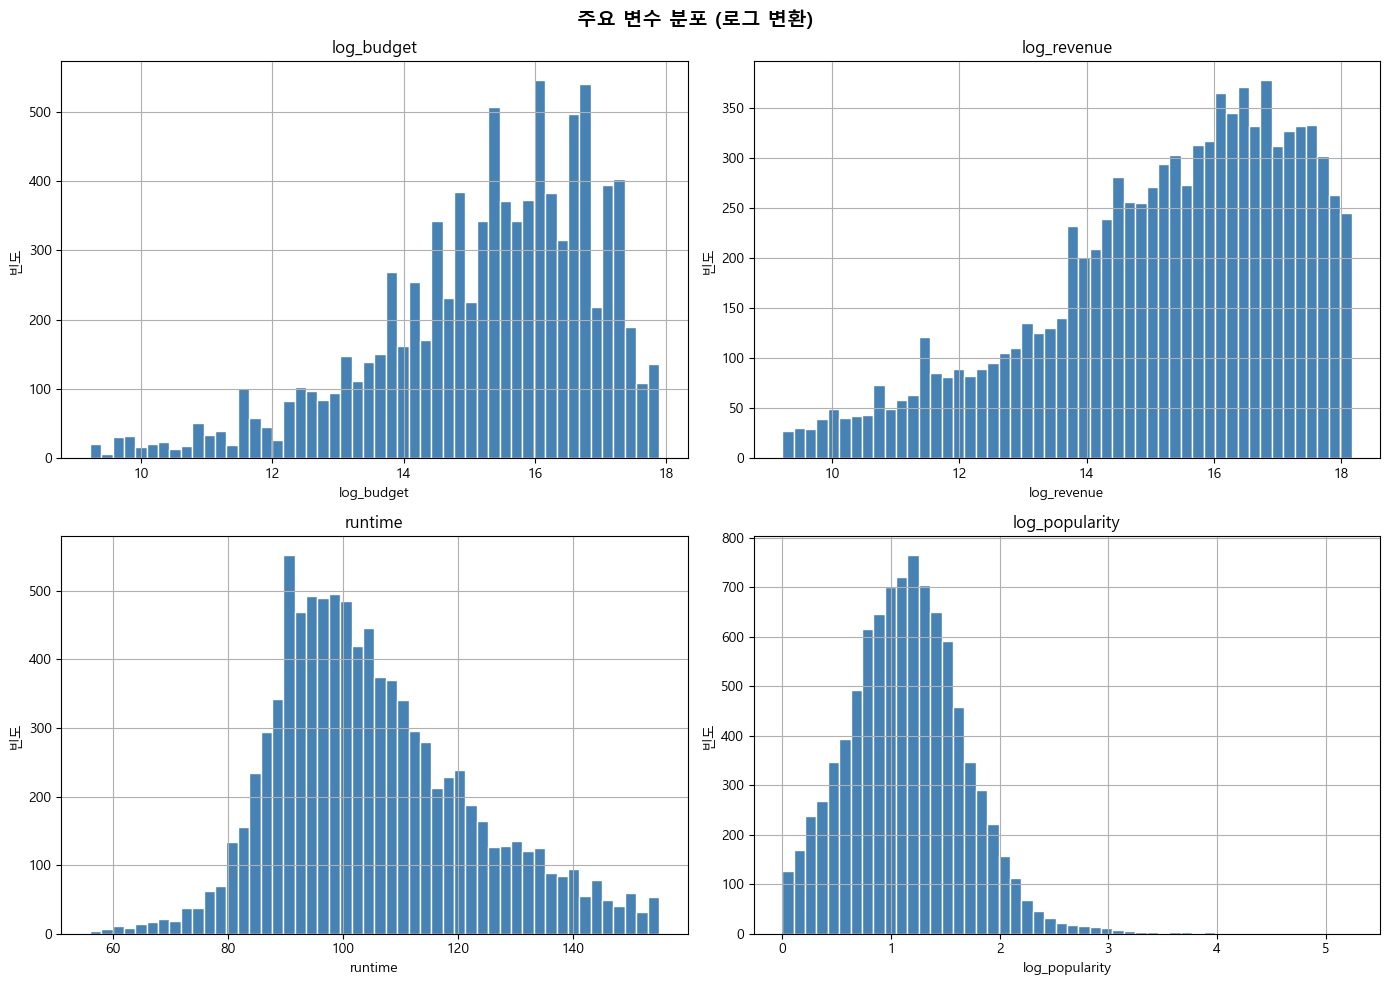

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), ['log_budget', 'log_revenue', 'runtime', 'log_popularity']):
    df[col].hist(ax=ax, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('빈도')
plt.suptitle('주요 변수 분포 (로그 변환)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 분석
- `log_budget`은 약 14와 16~17 구간에 두 개의 봉우리가 나타나는 쌍봉(bimodal) 분포를 보인다.
  최빈값이 두 개 존재하는 multi-modal 분포로, 저예산 독립영화와 고예산 블록버스터 집단이
  구조적으로 분리되어 있음을 시사한다.
- `log_revenue`는 로그 변환 후에도 우측으로 갈수록 빈도가 증가하는 치우침(Skewness)이 일부 잔존한다.
  하한 필터($10,000 초과) 적용으로 저수익 영화가 절단된 영향이다.
- `runtime`은 변환 없이도 80~110분 중심의 정규분포에 근접한 형태를 보여 추가 변환이 불필요하다.
- `log_popularity`는 로그 변환 효과가 가장 두드러지며, 1~2 구간에 집중된 안정적인 분포를 나타낸다.

### 박스플롯

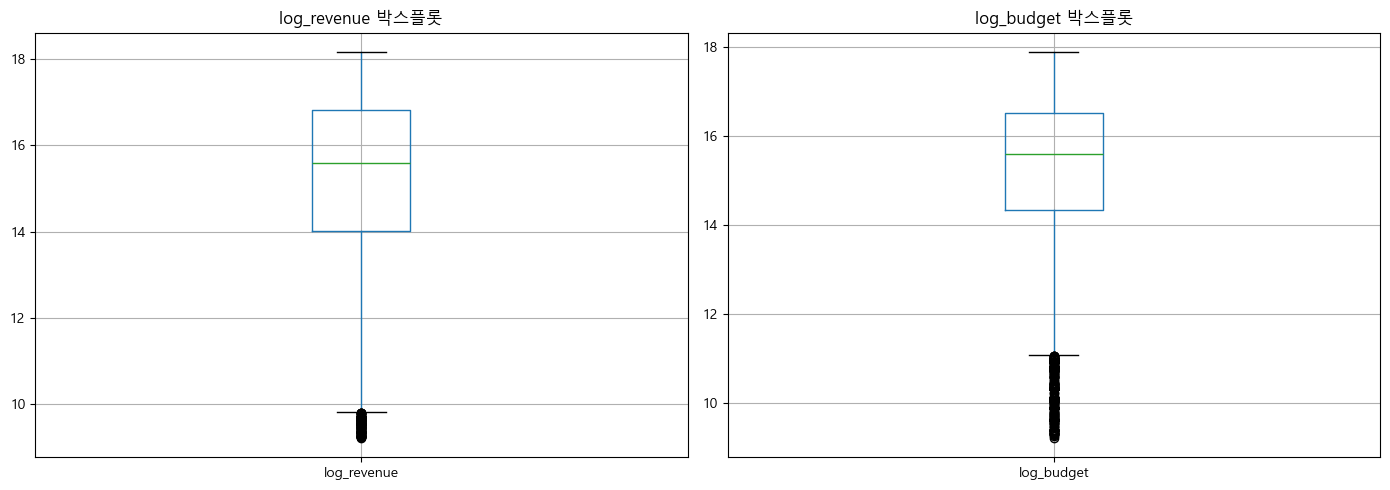

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.boxplot(column='log_revenue', ax=axes[0])
axes[0].set_title('log_revenue 박스플롯')
df.boxplot(column='log_budget', ax=axes[1])
axes[1].set_title('log_budget 박스플롯')
plt.tight_layout()
plt.show()

### 박스플롯

### 분석
- 박스 플롯의 5대 요약 수치(최솟값, Q1, 중앙값, Q3, 최댓값) 기준으로 두 변수를 비교한다.
- `log_revenue` 하단에 소수의 이상치(≈9.4)가 존재하며,
  평균으로부터 멀리 떨어진 데이터로 측정 오류 또는 극단적 저수익 케이스로 해석된다.
- `log_budget` 하단에는 IQR 범위를 크게 벗어나는 이상치가 다수 분포(≈9~11)하며,
  히스토그램에서 확인된 저예산 클러스터와 동일한 집단으로 해석된다.

## Step 4. 상관분석

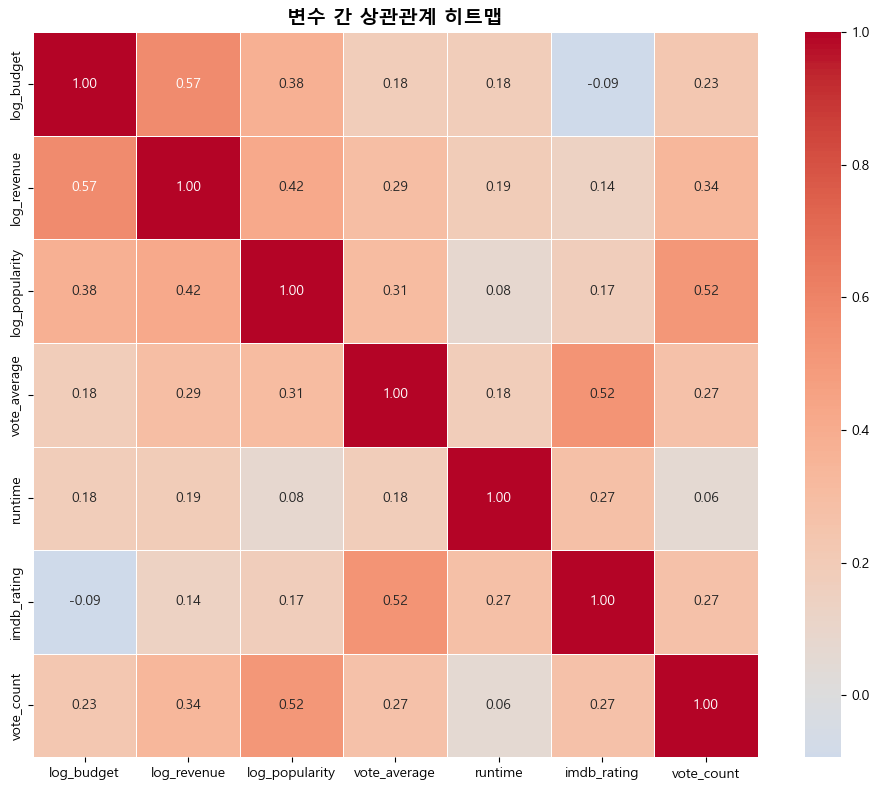

In [10]:
numeric_cols = ['log_budget', 'log_revenue', 'log_popularity', 'vote_average',
                'runtime', 'imdb_rating', 'vote_count']
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('변수 간 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 분석
- 피어슨 상관계수 기준으로 `log_revenue`와의 연관성을 분석한다.
- `log_budget`(r=0.57)이 가장 강한 양의 선형 관계를 보이며, 이어서
  `log_popularity`(0.42), `vote_count`(0.34), `vote_average`(0.29) 순이다.
- `vote_count`와 `imdb_votes` 간 r=0.93의 강한 양의 상관이 확인된다.
  두 변수가 함께 모델에 포함되면 변수 간 정보 중복으로 인해 모델의 강건성(Robustness)이
  저하될 수 있으므로 `imdb_votes`를 제거하였다.
- `vote_average`와 `imdb_rating` 간에도 r=0.73의 높은 상관이 나타나 평가 지표 간 중복성이 존재한다.

In [11]:
corr_revenue = df[numeric_cols].corr()['log_revenue'].sort_values(ascending=False)
print("log_revenue와의 상관계수:")
print(corr_revenue)

log_revenue와의 상관계수:
log_revenue       1.000000
log_budget        0.566092
log_popularity    0.422216
vote_count        0.344585
vote_average      0.292256
runtime           0.189291
imdb_rating       0.139180
Name: log_revenue, dtype: float64


가설 검증
- 예산(budget)이 높을수록 수익(revenue)이 높은 경향 확인


## 장르별 상관계수

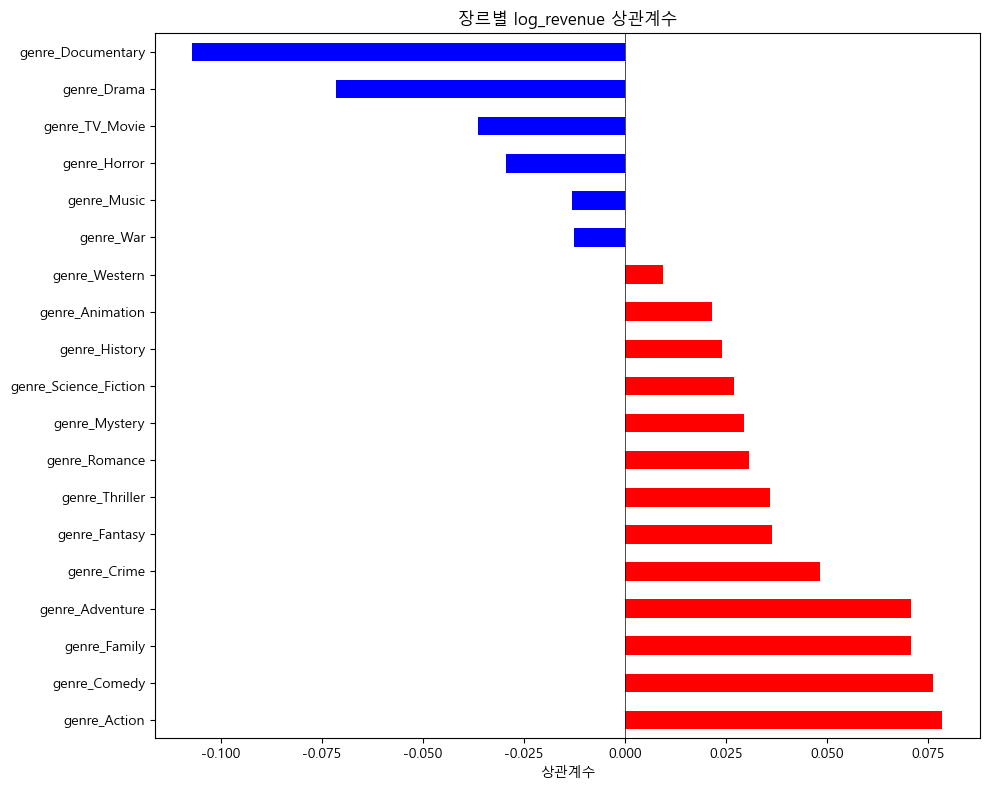

In [12]:
genre_cols = [c for c in df.columns if c.startswith('genre_')]
corr_genre = df[genre_cols + ['log_revenue']].corr()['log_revenue'].drop('log_revenue')
corr_genre = corr_genre.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr_genre.plot(kind='barh', 
    color=['red' if x > 0 else 'blue' for x in corr_genre])
plt.axvline(x=0, color='black', linewidth=0.5)
plt.title('장르별 log_revenue 상관계수')
plt.xlabel('상관계수')
plt.tight_layout()
plt.show()

### 수익성이 좋은 장르
| 장르 | 상관계수 |
|------|---------|
| 액션 | +0.076 |
| 코미디 | +0.074 |
| 패밀리 | +0.071 |
| 모험 | +0.069 |
| 범죄 | +0.048 |
| 판타지 | +0.038 |
| 스릴러 | +0.035 |

### 수익성이 나쁜 장르
| 장르 | 상관계수 |
|------|---------|
| 다큐멘터리 | -0.110 |
| 드라마 | -0.080 |
| TV 무비 | -0.065 |
| 호러 | -0.055 |

### 분석
- 범주형 예측 변수(장르)와 연속형 결과 변수(log_revenue) 간의 상관관계를 시각화한 결과이다.
- 액션(+0.076), 코미디(+0.074), 패밀리(+0.071) 장르가 수익과 양의 상관을 보이며,
  대규모 관객층을 대상으로 하는 장르일수록 흥행에 유리한 경향이 있다.
- 다큐멘터리(-0.110), 드라마(-0.080)는 수익과 음의 상관을 나타낸다.
  예술성 중심의 장르는 상업적 수익과 거리가 있음을 시사한다.
- 다만 장르 변수의 상관계수 절댓값은 최대 0.11로 낮아, 단독 예측 변수로서의 영향력은 제한적이다.

### 가설 검증
**가설 3** "특정 장르는 수익과 관련된 경향을 보인다" — 부분 채택
일부 장르에서 양/음의 상관이 확인되나 상관계수는 낮음

## Step 5. PCA (주성분분석)

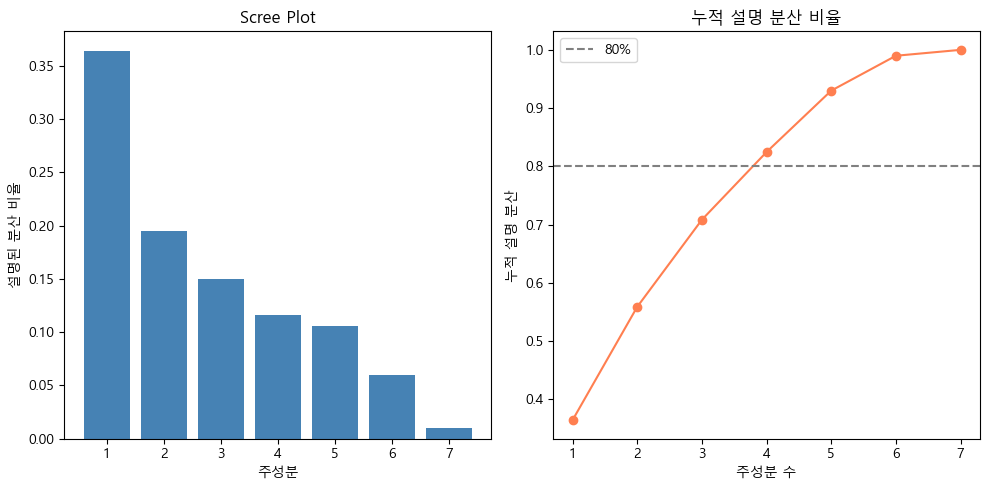

설명된 분산 비율:
  PC1: 0.3642 (0.3642 누적)
  PC2: 0.1945 (0.5587 누적)
  PC3: 0.1496 (0.7083 누적)
  PC4: 0.1163 (0.8246 누적)
  PC5: 0.1054 (0.9300 누적)
  PC6: 0.0599 (0.9899 누적)
  PC7: 0.0101 (1.0000 누적)


In [13]:
pca_cols = ['budget', 'popularity', 'vote_average', 'vote_count',
            'runtime', 'imdb_rating', 'imdb_votes']
X_pca = df_scaled[pca_cols].dropna()

pca = PCA()
pca.fit(X_pca)

explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained)+1), explained, color='steelblue')
plt.xlabel('주성분')
plt.ylabel('설명된 분산 비율')
plt.title('Scree Plot')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative)+1), cumulative, 'o-', color='coral')
plt.axhline(y=0.8, color='gray', linestyle='--', label='80%')
plt.xlabel('주성분 수')
plt.ylabel('누적 설명 분산')
plt.title('누적 설명 분산 비율')
plt.legend()
plt.tight_layout()
plt.show()

print("설명된 분산 비율:")
for i, v in enumerate(explained):
    print(f"  PC{i+1}: {v:.4f} ({cumulative[i]:.4f} 누적)")

### 분석
- 스크리 플롯(Scree Plot)의 X축은 주성분 순서, Y축은 각 주성분의 설명된 분산 비율을 나타낸다.
- PC1(36.4%)에서 PC2(19.5%)로의 급격한 감소 이후 완만해지는 엘보우(Elbow) 지점이
  PC3~PC4 구간에서 관찰된다.
- 누적 설명 분산 80% 기준을 충족하는 주성분 수는 **4개**(누적 82.5%)이며, 이후 분석에서 PC1~PC4를 사용한다.
- PCA는 비지도 학습(Unsupervised) 기반 차원축소로, 데이터의 분산(=정보량)을 최대한 보존하면서
  서로 직교하는 새로운 축을 찾는다.

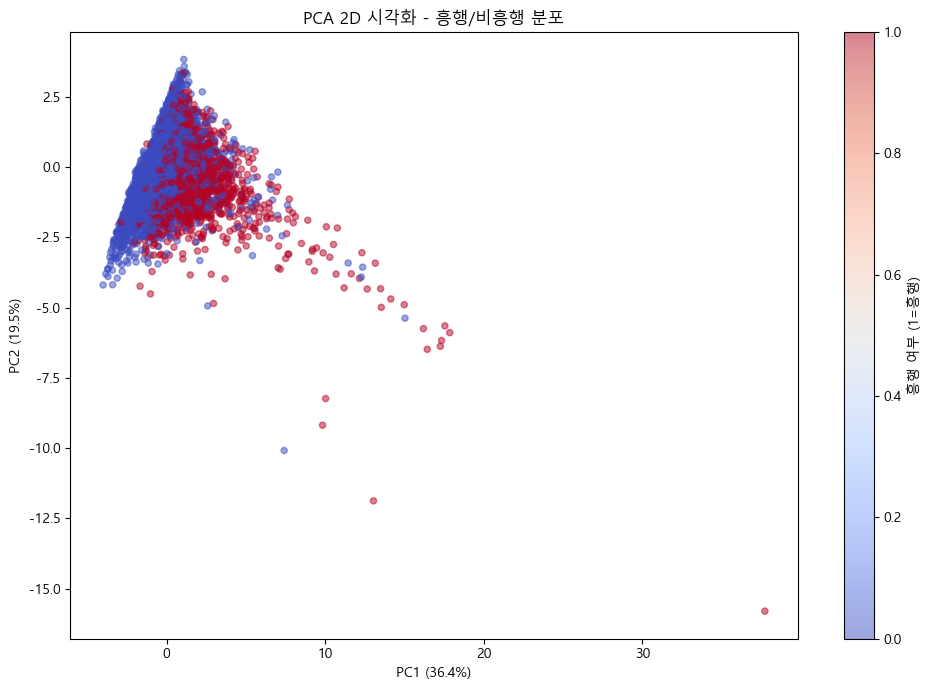

In [14]:
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_pca)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1],
                      c=df.loc[X_pca.index, 'hit'],
                      cmap='coolwarm', alpha=0.5, s=20)
plt.colorbar(scatter, label='흥행 여부 (1=흥행)')
plt.xlabel(f'PC1 ({explained[0]:.1%})')
plt.ylabel(f'PC2 ({explained[1]:.1%})')
plt.title('PCA 2D 시각화 - 흥행/비흥행 분포')
plt.tight_layout()
plt.show()

### 분석
- 원본 데이터를 PC1과 PC2 두 개의 주성분 축으로 투영하여 시각화한 결과이다.
- PC1(36.4%) 방향으로 흥행 영화(빨강)가 오른쪽에 편향되는 경향이 확인된다.
  PC1이 수익과 관련된 분산 정보를 주로 압축하고 있음을 시사한다.
- 메인 클러스터 내부에서 흥행/비흥행이 혼재하여 선형 분리가 어렵다.
  PCA는 클래스 라벨을 활용하지 않는 비지도 학습 기반 차원축소로,
  클래스 분리를 목적으로 하는 LDA와 달리 분산 최대화가 목적이므로 이는 자연스러운 결과이다.
- 우하단의 극단 이상치(PC1≈35, PC2≈-16)는 `popularity` 이상치 미처리와 관련된 것으로 추정되며,
  PCA는 이상치에 민감하다는 한계를 보여준다.

## Step 6. 모델 학습 및 평가

In [15]:
feature_cols = ['budget', 'popularity', 'vote_average', 'vote_count',
                'runtime', 'imdb_rating', 'year', 'month',
                'director_is_top', 'actor_is_top']
genre_cols = [c for c in df_scaled.columns if c.startswith('genre_')]
feature_cols = feature_cols + genre_cols

X = df_scaled[feature_cols].dropna()

df['log_revenue'] = np.log1p(df['revenue'])
y = df.loc[X.index, 'log_revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"학습 데이터: {X_train.shape}")
print(f"테스트 데이터: {X_test.shape}")

학습 데이터: (7422, 29)
테스트 데이터: (1856, 29)


In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== 선형 회귀 성능 ===")
print(f"RMSE: {rmse_lr:,.0f}")
print(f"MAE:  {mae_lr:,.0f}")
print(f"R²:   {r2_lr:.4f}")

=== 선형 회귀 성능 ===
RMSE: 2
MAE:  1
R²:   0.3686


In [17]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("=== 랜덤 포레스트 성능 ===")
print(f"RMSE: {rmse_rf:,.0f}")
print(f"MAE:  {mae_rf:,.0f}")
print(f"R²:   {r2_rf:.4f}")

=== 랜덤 포레스트 성능 ===
RMSE: 1
MAE:  1
R²:   0.5265


In [18]:
results = pd.DataFrame({
    '모델': ['선형 회귀', '랜덤 포레스트'],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE':  [mae_lr, mae_rf],
    'R²':   [r2_lr, r2_rf]
})
print(results.to_string(index=False))

     모델     RMSE      MAE       R²
  선형 회귀 1.616664 1.258799 0.368603
랜덤 포레스트 1.399942 1.054289 0.526539


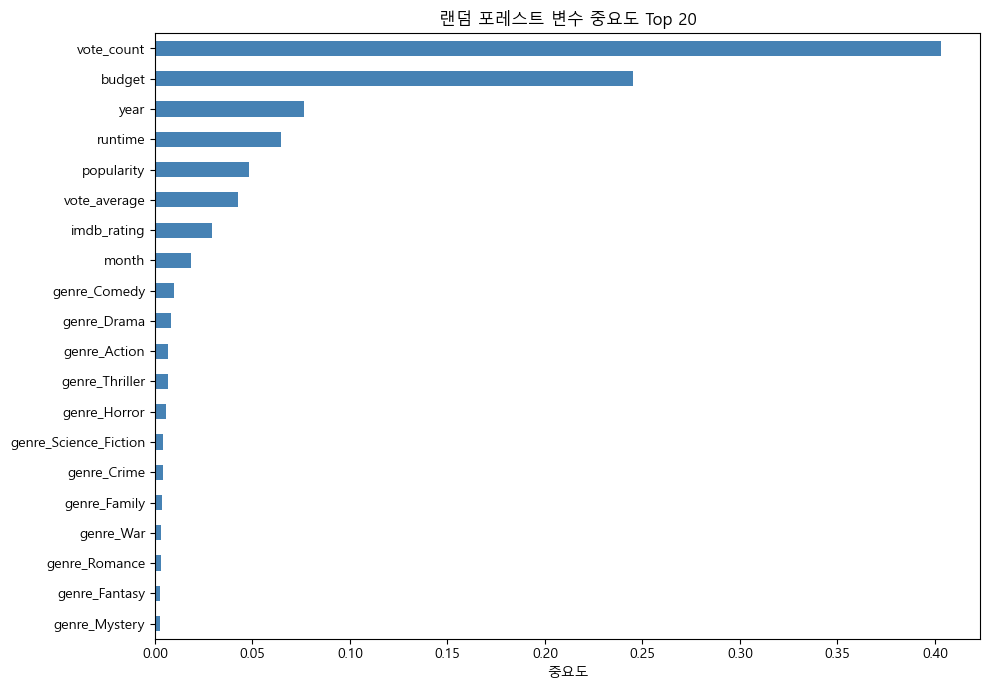

In [19]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20)

plt.figure(figsize=(10, 7))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('랜덤 포레스트 변수 중요도 Top 20')
plt.xlabel('중요도')
plt.tight_layout()
plt.show()

## Step 7. 결론 및 인사이트

### 7-1. 분석 결과 요약

| 분석 단계 | 핵심 결과 |
|-----------|-----------|
| 상관분석 | log_budget(0.57) > log_popularity(0.42) > vote_count(0.34) 순으로 수익과 양의 상관 |
| 장르 | Action·Comedy·Family 유리 / Documentary·Drama 불리 |
| PCA | 4개 주성분으로 분산 82.5% 설명 |
| 선형 회귀 | R²=0.369, RMSE=1.617 (log 스케일) |
| 랜덤 포레스트 | R²=0.527, RMSE=1.400 (log 스케일) |

랜덤 포레스트가 선형 회귀 대비 R² 기준 약 16%p 높은 성능을 보였으며,
영화 수익 결정 구조가 단순 선형 관계로 설명되지 않음을 시사한다.

---

### 7-2. vote_count 제거가 필요한 이유

본 모델에서 `vote_count`는 랜덤 포레스트 변수 중요도 1위(0.40)를 차지했으나,
다음과 같은 이유로 예측 변수로서 적합하지 않다.

1. **사후 지표 문제**: `vote_count`는 개봉 이후 관객이 누적 투표한 값이다.
   수익이 발생하는 시점과 동시에, 혹은 그 이후에 쌓이는 구조이므로
   개봉 **전** 수익 예측이라는 본 프로젝트의 목표와 부합하지 않는다.

2. **역인과 관계**: 흥행했기 때문에 투표 수가 많은 것인지,
   투표 수가 많아서 흥행한 것인지 방향을 특정할 수 없다.

3. **실용성 부재**: 실제 개봉 전 시나리오에서 `vote_count`는 알 수 없는 값이므로
   예측 모델 입력 변수로 활용이 불가능하다.

따라서 `vote_count`, `imdb_votes`를 제거한 모델(`movie_analysis_no_votes`)을 별도로 구성하여 비교한다.

---

### 7-3. 가설 검증 결과

| 가설 | 내용 | 결과 | 근거 |
|------|------|------|------|
| 가설 1 | 제작 예산이 높을수록 수익이 높다 | ✅ 채택 | log_budget ↔ log_revenue r=0.57 |
| 가설 2 | 인기도(popularity)가 높을수록 수익이 높다 | ✅ 채택 | log_popularity ↔ log_revenue r=0.42 |
| 가설 3 | 특정 장르는 수익과 관련된 경향을 보인다 | 부분 채택 | 일부 장르에서 양/음의 상관 확인, 상관계수는 낮음 |
| 가설 4 | 랜덤 포레스트가 선형 회귀보다 예측 성능이 높다 | ✅ 채택 | RF R²=0.527 vs 선형 회귀 R²=0.369 |

---

### 7-4. 주요 인사이트

- **예산이 흥행의 가장 강력한 사전 예측 변수다.**
  상관분석과 모델 변수 중요도 모두에서 budget이 상위권을 차지했다.

- **vote_count가 모델 내 1위 변수이나 해석에 주의가 필요하다.**
  vote_count는 개봉 이후 관객이 누적 투표한 사후 지표로, 역인과 관계가 존재한다.
  개봉 전 수익 예측 시나리오에서는 활용이 제한적이다.

- **장르는 수익에 관련된 경향을 보이나 영향력은 제한적이다.**
  Action, Comedy, Family 장르가 수익에 긍정적 경향을 보인 반면,
  Documentary, Drama는 부정적 경향을 나타냈다.
  다만 랜덤 포레스트 변수 중요도에서 장르 변수들은 모두 0.01~0.02 수준으로 낮다.

- **비선형 모델이 영화 수익 예측에 더 적합하다.**
  랜덤 포레스트가 선형 회귀 대비 R² 기준 약 16%p 높은 성능을 보였다.
  이는 영화 수익 결정 구조가 단순 선형 관계로 설명되지 않음을 시사한다.

---

### 7-5. 한계점 및 개선 방향

**한계점**
- R²=0.527로 수익 분산의 약 47%는 본 모델로 설명되지 않는다.
  마케팅 비용, 경쟁작 개봉 일정, 사회적 이슈 등 비정형 요인이 반영되지 않았다.
- `vote_count`의 사후 지표 문제: 개봉 전 수익 예측 시나리오에서 활용이 제한적이다.
- `vote_average`, `imdb_rating` 역시 수집 시점에 따라 사후성이 포함될 수 있어,
  본 모델은 완전한 개봉 전 예측 모델이라기보다
  사후 지표 의존도를 낮춘 흥행 요인 분석 모델로 해석하는 것이 적절하다.
- budget·revenue $10,000 초과 영화로 한정되어 저예산 독립영화 일반화 제한
- `popularity` 이상치 미처리로 모델 성능에 일부 영향 가능성 존재

**개선 방향**
- `vote_count`, `imdb_votes` 제거 후 순수 사전 변수 기반 모델로 재구성 → `movie_analysis_no_votes` 참조
- `popularity` 이상치 처리 적용 후 성능 변화 확인
- 개봉 월·계절 등 시간 변수 추가 탐색